## TUGAS PROYEK KELOMPOK 1 (P1)
### Evaluasi Kinerja Model Klasifikasi

#### Kelompok 2
1. Galih Najwa Pradipta (245150200111009)
2. Muhammad Fahmi Yakhsya (245150200111011)
3. Anasya Laili Rahmadani (245150200111013)
4. Nayla Masyitha Ramadhani (245150200111016)
5. Hassan Nashrallah (245150200111025)

### 1) Import Dataset
Dataset yang kami pilih adalah Bank Marketing Dataset yang diperoleh dari UCI Machine Learning Repository.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


###2) Eksplorasi dan Pemahaman Data

===== 5 Data Pertama =====
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

===== Shape Dataset =====
(11162, 17)

===== Informasi Dataset =====
<c

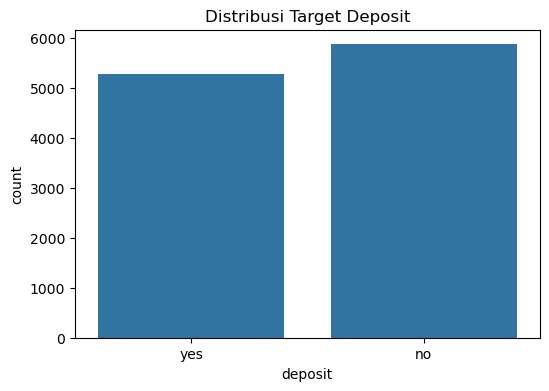


Fitur Numerik: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Fitur Kategorikal: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


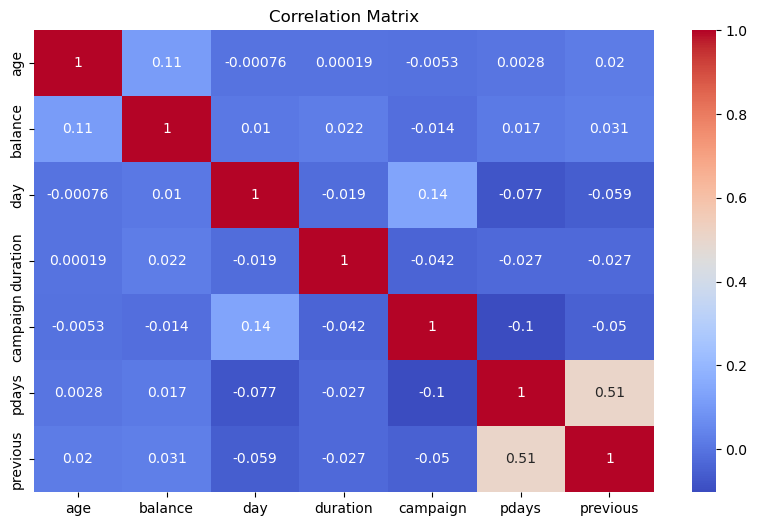

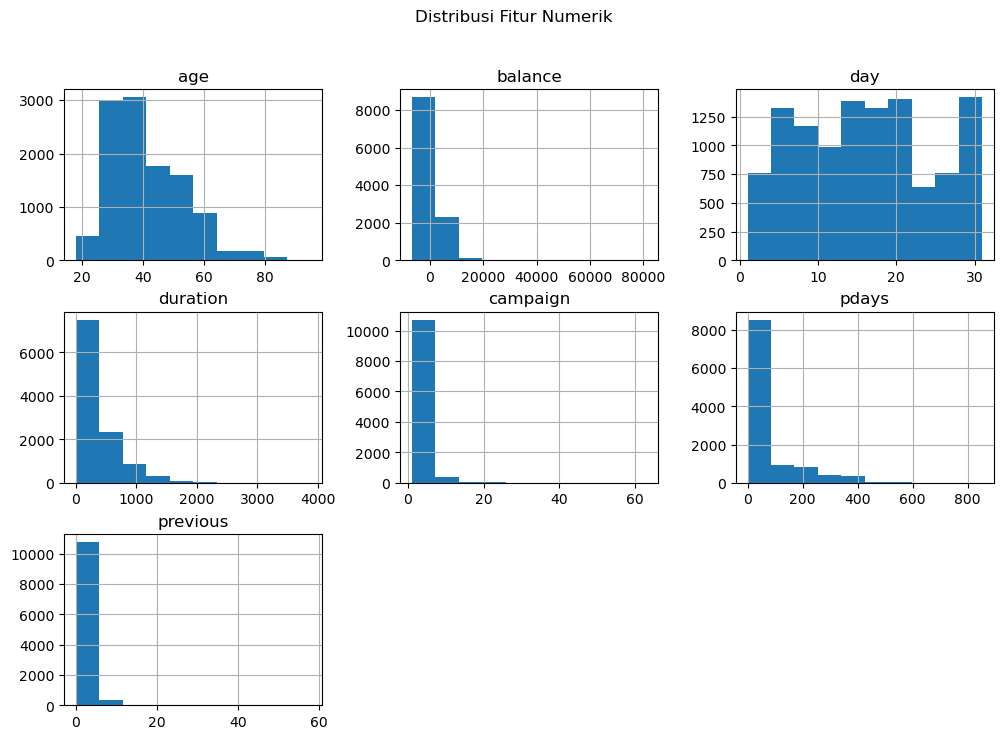

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("C:/Users/hassa/OneDrive/Dokumen/praktikumz/kal-praktikum/data/bank.csv")

# 1. Melihat 5 data pertama
print("===== 5 Data Pertama =====")
print(data.head())

# 2. Ukuran dataset
print("\n===== Shape Dataset =====")
print(data.shape)

# 3. Informasi dataset
print("\n===== Informasi Dataset =====")
print(data.info())

# 4. Statistik deskriptif
print("\n===== Statistik Dataset =====")
print(data.describe(include="all"))

# 5. Missing value
print("\n===== Missing Value =====")
print(data.isnull().sum())

# 6. Distribusi target
print("\n===== Distribusi Target (deposit) =====")
print(data['deposit'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=data)
plt.title("Distribusi Target Deposit")
plt.show()

# 7. Identifikasi fitur numerik dan kategorikal
numerical_features = data.select_dtypes(include=['int64','float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

print("\nFitur Numerik:", list(numerical_features))
print("Fitur Kategorikal:", list(categorical_features))

# 8. Korelasi fitur numerik
plt.figure(figsize=(10,6))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 9. Distribusi fitur numerik
data[numerical_features].hist(figsize=(12,8))
plt.suptitle("Distribusi Fitur Numerik")
plt.show()

###3) Data Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# 1. Pisahkan fitur dan target
X = data.drop("deposit", axis=1)
y = data["deposit"]

# 2. Encode target (yes/no → 1/0)
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Identifikasi fitur numerik dan kategorikal
numerical_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 5. Pipeline numerik
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 6. Pipeline kategorikal
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# 7. ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

# 8. Fit dan transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape data train setelah preprocessing:", X_train_processed.shape)
print("Shape data test setelah preprocessing:", X_test_processed.shape)

Shape data train setelah preprocessing: (8929, 51)
Shape data test setelah preprocessing: (2233, 51)


###4) Model Klasifikasi

Accuracy KNN: 0.8172861621137483

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1175
           1       0.82      0.79      0.80      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



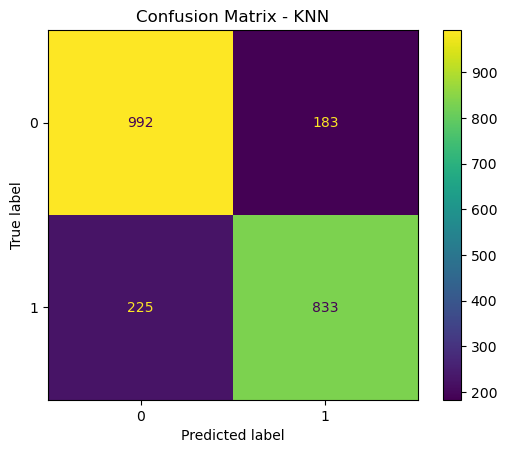

In [3]:
# Model Klasifikasi - KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Pipeline: preprocessing + model
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Training model
knn_model.fit(X_train, y_train)

# Prediksi data test
y_pred_knn = knn_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy KNN:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

Accuracy Random Forest: 0.8620689655172413

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.86      1175
           1       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



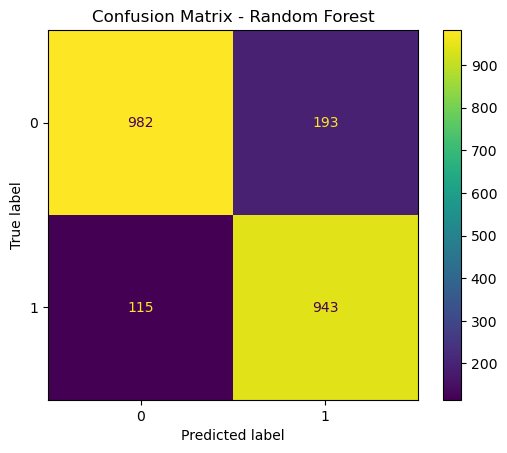

In [5]:
#Model Klasifikasi - Random Forest
from sklearn.ensemble import RandomForestClassifier

# Pipeline Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Training model
rf_model.fit(X_train, y_train)

# Prediksi data test
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Accuracy SVM: 0.8553515450067174

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.82      0.88      0.85      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



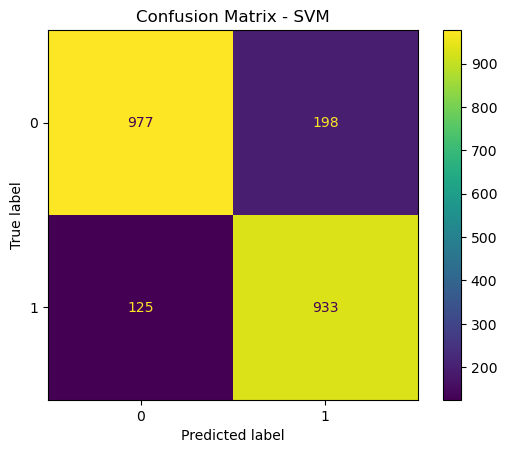

In [6]:
#Model Klasifikasi - SVM
from sklearn.svm import SVC

# Pipeline SVM
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=42, probability=True))
])

# Training model
svm_model.fit(X_train, y_train)

# Prediksi data test
y_pred_svm = svm_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

###5) Tuning Hyperparameter

Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
Best CV Score: 0.812295758168889
Accuracy KNN (Tuned): 0.825794894760412

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1175
           1       0.83      0.79      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233



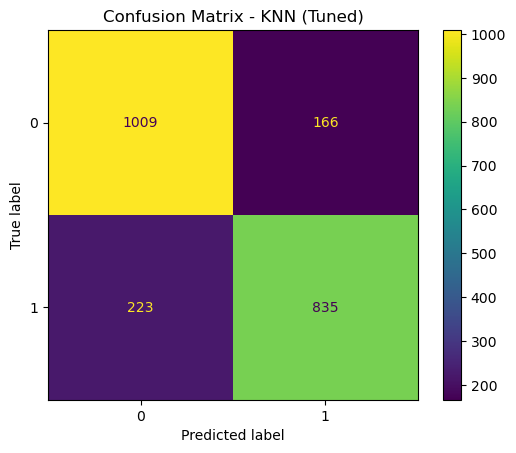

In [4]:
# Tuning KNN
from sklearn.model_selection import GridSearchCV

# Parameter grid untuk tuning KNN
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],     # Jumlah tetangga
    'classifier__weights': ['uniform', 'distance'],       # Bobot
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']  # Metrik jarak
}

# GridSearchCV
knn_grid = GridSearchCV(
    knn_model,
    param_grid_knn,
    cv=5,                           # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1                       # Gunakan semua processor
)

# Training model dengan GridSearch
knn_grid.fit(X_train, y_train)

# Model terbaik
best_knn_model = knn_grid.best_estimator_

# Prediksi data test
y_pred_knn = best_knn_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_knn)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)
print("Accuracy KNN (Tuned):", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - KNN (Tuned)")
plt.show()

Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
Best CV Score: 0.8519426852487916
Accuracy Random Forest (Tuned): 0.8593819973130318

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      1175
           1       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



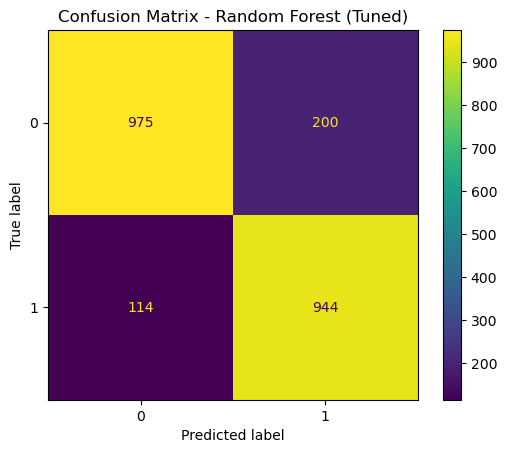

In [7]:
# Tuning Random Forest
# Parameter grid untuk tuning
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
rf_grid = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Training model dengan GridSearch
rf_grid.fit(X_train, y_train)

# Model terbaik
best_rf_model = rf_grid.best_estimator_

# Prediksi data test
y_pred_rf = best_rf_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_rf)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)
print("Accuracy Random Forest (Tuned):", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.show()

Best Parameters: {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV Score: 0.8528385419117255
Accuracy SVM (Tuned): 0.8593819973130318

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1175
           1       0.83      0.88      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



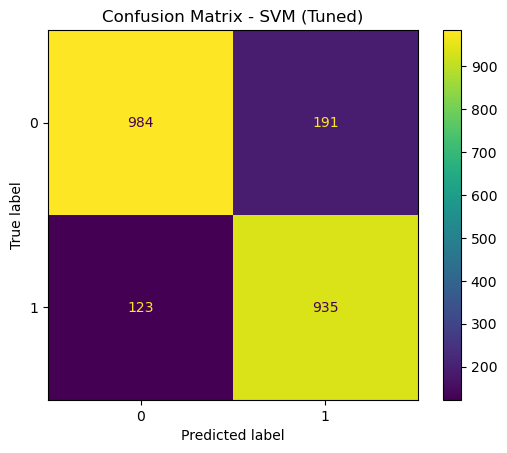

In [8]:
# Tuning SVM
# Parameter grid untuk tuning
param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.1],
    'classifier__kernel': ['rbf', 'poly']
}

# GridSearchCV
svm_grid = GridSearchCV(
    svm_model,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Training model dengan GridSearch
svm_grid.fit(X_train, y_train)

# Model terbaik
best_svm_model = svm_grid.best_estimator_

# Prediksi data test
y_pred_svm = best_svm_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_svm)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)
print("Accuracy SVM (Tuned):", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM (Tuned)")
plt.show()


###6) Evaluasi Model

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = None

    return acc, prec, rec, f1, auc

In [10]:
# Evaluasi model KNN
# Prediksi
y_pred = knn_model.predict(X_test)
y_pred_tuned = best_knn_model.predict(X_test)

# ROC-AUC
y_prob = knn_model.predict_proba(X_test)[:, 1]
y_prob_tuned = best_knn_model.predict_proba(X_test)[:, 1]

# Model tanpa tuning
acc, prec, rec, f1, auc = evaluate_model(y_test, y_pred, y_prob)

# Model dengan tuning
acc_t, prec_t, rec_t, f1_t, auc_t = evaluate_model(y_test, y_pred_tuned, y_prob_tuned)

print("Evaluasi Model KNN")
print("=== Tanpa Tuning ===")
print(f"Akurasi  : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n=== Dengan Tuning ===")
print(f"Akurasi  : {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-score : {f1_t:.4f}")
print(f"ROC-AUC  : {auc_t:.4f}")

Evaluasi Model KNN
=== Tanpa Tuning ===
Akurasi  : 0.8173
Precision: 0.8199
Recall   : 0.7873
F1-score : 0.8033
ROC-AUC  : 0.8796

=== Dengan Tuning ===
Akurasi  : 0.8258
Precision: 0.8342
Recall   : 0.7892
F1-score : 0.8111
ROC-AUC  : 0.8974


In [11]:
# Evaluasi model Random Forest
# Prediksi
y_pred = rf_model.predict(X_test)
y_pred_tuned = best_rf_model.predict(X_test)

# ROC-AUC
y_prob = rf_model.predict_proba(X_test)[:, 1]
y_prob_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Model tanpa tuning
acc, prec, rec, f1, auc = evaluate_model(y_test, y_pred, y_prob)

# Model dengan tuning
acc_t, prec_t, rec_t, f1_t, auc_t = evaluate_model(y_test, y_pred_tuned, y_prob_tuned)

print("Evaluasi Model Random Forest")
print("=== Tanpa Tuning ===")
print(f"Akurasi  : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n=== Dengan Tuning ===")
print(f"Akurasi  : {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-score : {f1_t:.4f}")
print(f"ROC-AUC  : {auc_t:.4f}")

Evaluasi Model Random Forest
=== Tanpa Tuning ===
Akurasi  : 0.8621
Precision: 0.8301
Recall   : 0.8913
F1-score : 0.8596
ROC-AUC  : 0.9193

=== Dengan Tuning ===
Akurasi  : 0.8594
Precision: 0.8252
Recall   : 0.8922
F1-score : 0.8574
ROC-AUC  : 0.9219


In [12]:
# Evaluasi model SVM
# Prediksi
y_pred = svm_model.predict(X_test)
y_pred_tuned = best_svm_model.predict(X_test)

# ROC-AUC
y_prob = svm_model.predict_proba(X_test)[:, 1]
y_prob_tuned = best_svm_model.predict_proba(X_test)[:, 1]

# Model tanpa tuning
acc, prec, rec, f1, auc = evaluate_model(y_test, y_pred, y_prob)

# Model dengan tuning
acc_t, prec_t, rec_t, f1_t, auc_t = evaluate_model(y_test, y_pred_tuned, y_prob_tuned)

print("Evaluasi Model SVM")
print("=== Tanpa Tuning ===")
print(f"Akurasi  : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n=== Dengan Tuning ===")
print(f"Akurasi  : {acc_t:.4f}")
print(f"Precision: {prec_t:.4f}")
print(f"Recall   : {rec_t:.4f}")
print(f"F1-score : {f1_t:.4f}")
print(f"ROC-AUC  : {auc_t:.4f}")

Evaluasi Model SVM
=== Tanpa Tuning ===
Akurasi  : 0.8554
Precision: 0.8249
Recall   : 0.8819
F1-score : 0.8524
ROC-AUC  : 0.9194

=== Dengan Tuning ===
Akurasi  : 0.8594
Precision: 0.8304
Recall   : 0.8837
F1-score : 0.8562
ROC-AUC  : 0.9228


In [13]:
# Performa antar model
models = {
    "K-Nearest Neighbor": knn_model,
    "Random Forest": rf_model,
    "Support Vector Machine": svm_model
}

for name, m in models.items():
    y_pred = m.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")

K-Nearest Neighbor: 0.8173
Random Forest: 0.8621
Support Vector Machine: 0.8554
